In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
class Backtest:
    def __init__(self, ticker, start, end, short=20, long=50):
        self.ticker = ticker
        self.start  = start
        self.end    = end
        self.short  = short
        self.long   = long
        self.data   = None
        self.results = None

    def fetch_data(self):
        df = yf.download(self.ticker, start=self.start, end=self.end)
        self.data = df[['Close']].copy()
        self.data.columns=['price']
        print(f"Loaded {len(self.data)} rows for {self.ticker}")

    def generate_signals(self):
        df = self.data.copy()
        df['SMA_short'] = df['price'].rolling(self.short).mean()
        df['SMA_long']  = df['price'].rolling(self.long).mean()
        df['signal']    = np.where(
            df['SMA_short'] > df['SMA_long'], 1.0, 0.0
        )
        # shift(1) — avoid look ahead bias
        df['position']  = df['signal'].shift(1)
        self.data = df
        print("Signals generated!")

    def calculate_performance(self):
        df = self.data.copy()

        # Daily returns
        df['market_return']   = df['price'].pct_change()

        # Strategy returns — only when position = 1 (holding)
        df['strategy_return'] = df['market_return'] * df['position']

        # Cumulative returns
        df['market_cum']   = (1 + df['market_return']).cumprod()
        df['strategy_cum'] = (1 + df['strategy_return']).cumprod()

        # Drop NaN rows
        df = df.dropna()

        # Sharpe Ratio
        daily_rf = 0.02 / 252
        excess   = df['strategy_return'] - daily_rf
        sharpe   = round(excess.mean() / excess.std() * np.sqrt(252), 2)

        # CAGR
        n_years = len(df) / 252
        cagr    = round((df['strategy_cum'].iloc[-1] ** (1/n_years) - 1) * 100, 2)

        # Max Drawdown
        rolling_max = df['strategy_cum'].cummax()
        drawdown    = (df['strategy_cum'] - rolling_max) / rolling_max
        max_dd      = round(drawdown.min() * 100, 2)

        self.results = df

        print(f"\n{'='*40}")
        print(f"  {self.ticker} Backtest Results")
        print(f"{'='*40}")
        print(f"  Sharpe Ratio:   {sharpe}")
        print(f"  CAGR:           {cagr}%")
        print(f"  Max Drawdown:   {max_dd}%")
        print(f"  Final Strategy: ${round(df['strategy_cum'].iloc[-1]*100, 2)}")
        print(f"  Final Market:   ${round(df['market_cum'].iloc[-1]*100, 2)}")
        print(f"{'='*40}")

        return sharpe, cagr, max_dd

    def plot(self):
        df = self.results
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        fig.suptitle(f'{self.ticker} Backtest — SMA{self.short}/SMA{self.long}', 
                     fontsize=14, fontweight='bold')

        # Plot 1 — Price + Moving Averages
        axes[0].plot(df['price'],     label='Price',              color='black', linewidth=1)
        axes[0].plot(df['SMA_short'], label=f'SMA{self.short}',  color='blue',  linewidth=1)
        axes[0].plot(df['SMA_long'],  label=f'SMA{self.long}',   color='red',   linewidth=1)
        axes[0].set_title('Price & Moving Averages')
        axes[0].legend()
        axes[0].set_ylabel('Price ($)')

        # Plot 2 — Strategy vs Market
        axes[1].plot(df['strategy_cum'] * 100, label='Strategy', color='green', linewidth=1.5)
        axes[1].plot(df['market_cum'] * 100,   label='Market',   color='blue',  linewidth=1.5)
        axes[1].axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
        axes[1].set_title('Strategy vs Market (Starting $100)')
        axes[1].legend()
        axes[1].set_ylabel('Portfolio Value ($)')

        # Plot 3 — Drawdown
        rolling_max = df['strategy_cum'].cummax()
        drawdown    = (df['strategy_cum'] - rolling_max) / rolling_max * 100
        axes[2].fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
        axes[2].set_title('Strategy Drawdown')
        axes[2].set_ylabel('Drawdown (%)')
        axes[2].set_xlabel('Date')

        plt.tight_layout()
        plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Chart saved as backtest_results.png")

    def run(self):
        self.fetch_data()
        self.generate_signals()
        self.calculate_performance()
        self.plot()

    def __str__(self):
        return f"Backtest({self.ticker}, {self.start} → {self.end}, SMA{self.short}/SMA{self.long})"

Backtest(AAPL, 2020-01-01 → 2024-01-01, SMA20/SMA50)


/var/folders/64/xz573gks0_g0yncbndhjq6fm0000gn/T/ipykernel_70172/3208941684.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start, end=self.end)
[*********************100%***********************]  1 of 1 completed


Loaded 1006 rows for AAPL
Signals generated!

  AAPL Backtest Results
  Sharpe Ratio:   0.65
  CAGR:           14.83%
  Max Drawdown:   -29.09%
  Final Strategy: $169.08
  Final Market:   $263.19


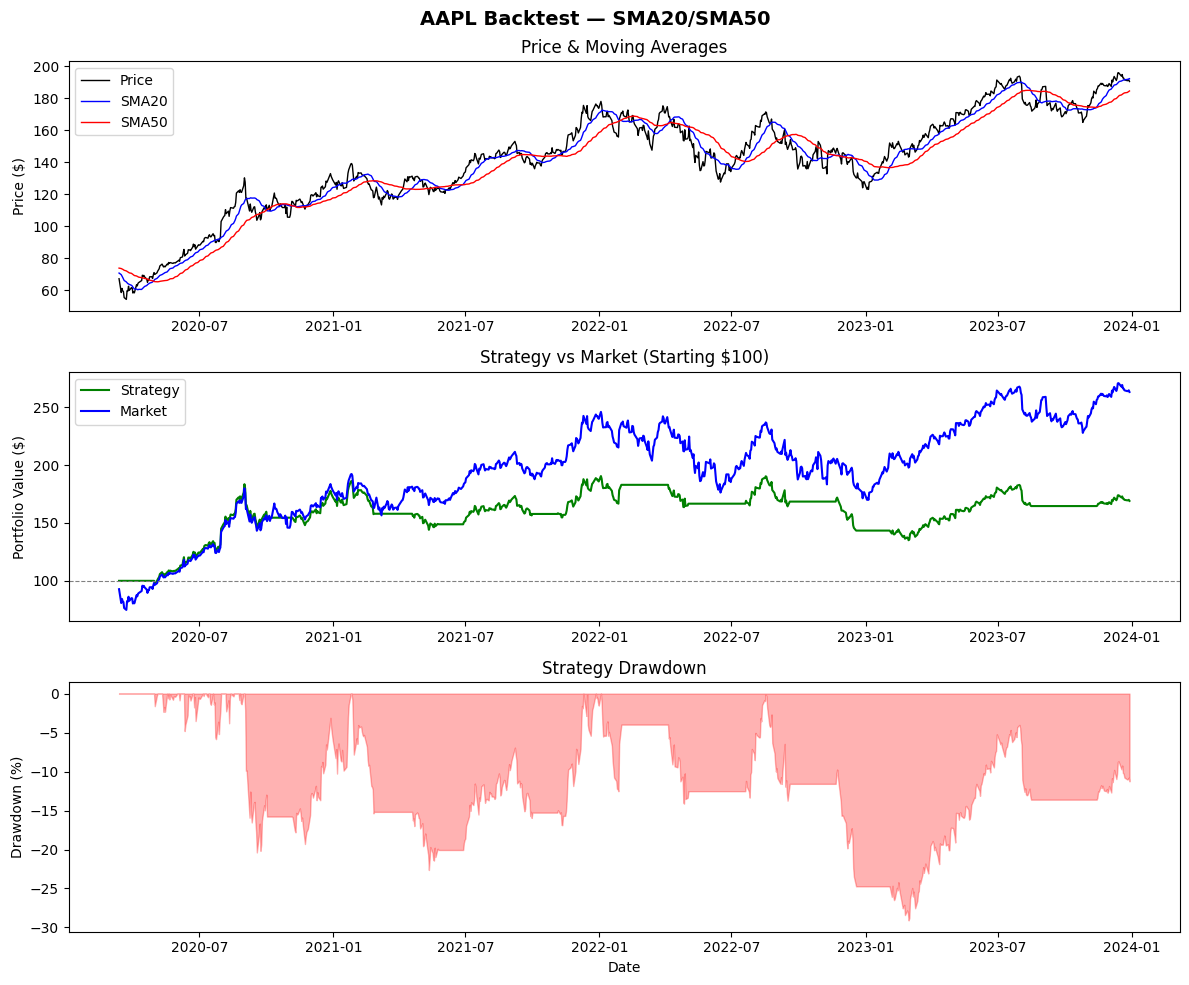

Chart saved as backtest_results.png


In [3]:
bt = Backtest("AAPL", "2020-01-01", "2024-01-01", short=20, long=50)
print(bt)
bt.run()